# Регрессия для прогнозирования IC50

Цель ноутбука -> построить и сравнить модели регрессии для прогнозирования значения `IC50, mM` по молекулярным дескрипторам химических соединений.

`IC50` показывает концентрацию соединения, необходимую для подавления биологической активности на 50%.
В контексте поиска потенциальных лекарственных соединений меньшие значения `IC50` обычно соответствуют большей активности соединения.

В данном эксперименте используются только молекулярные дескрипторы.
Служебные столбцы и целевые показатели `IC50, mM`, `CC50, mM`, `SI` исключаются из признакового пространства, чтобы избежать утечки данных.

## Импорты

In [7]:
# Библиотека для работы с предупреждениями
import warnings
# Библиотеки для работы с данными
import pandas as pd
# Разделение данных
from sklearn.model_selection import train_test_split
# Конфигурация проекта
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.config import (
    METRICS_DIR,
    PREDICTIONS_DIR,
    RANDOM_STATE,
    TARGET_IC50,
    TEST_SIZE,
)
# Загрузка данных
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.data_loader import load_coursework_dataset
# Запуск эксперимента
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.experiment_runner import (
    run_regression_experiment,
)
# Фабрика моделей
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.model_factory import get_regression_models
# Запуск экспериментов и визуализация
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.plotting import (
    plot_actual_vs_predicted,
    plot_regression_results,
)
# Подготовка признаков и целевой переменной
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.preprocessing import (
    build_features,
    build_regression_target,
    preprocess_features,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

METRICS_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

## Загрузка данных

In [8]:
df = load_coursework_dataset()

df.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,...,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.2394,175.4824,28.1250,5.0941,5.0941,0.3872,0.3872,0.4174,42.9286,384.6520,340.3000,384.3504,158,0,0.0388,-0.2935,0.2935,0.0388,0.6429,1.0357,1.3214,14.8223,9.7005,2.6005,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
1,1,0.7718,5.4028,7.0000,3.9614,3.9614,0.5339,0.5339,0.4625,45.2143,388.6840,340.3000,388.3817,162,0,0.0129,-0.3134,0.3134,0.0129,0.6071,1.0000,1.2857,14.9751,9.6892,2.6141,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
2,2,223.8088,161.1423,0.7200,2.6271,2.6271,0.5432,0.5432,0.2609,42.1875,446.8080,388.3440,446.4589,186,0,0.0948,-0.3256,0.3256,0.0948,0.5625,0.9062,1.1562,15.3539,9.6813,2.6653,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,3,0
3,3,1.7056,107.8557,63.2353,5.0974,5.0974,0.3906,0.3906,0.3778,41.8621,398.6790,352.3110,398.3661,164,0,0.0388,-0.2935,0.2935,0.0388,0.6207,1.0000,1.3103,14.8212,9.7005,2.6005,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0
4,4,107.1315,139.2710,1.3000,5.1505,5.1505,0.2705,0.2705,0.4290,36.5143,466.7130,424.3770,466.3348,184,0,0.0629,-0.2572,0.2572,0.0629,0.6000,0.9714,1.2571,14.8311,9.7004,2.6025,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Подготовка признаков и целевой переменной

In [9]:
X = build_features(df)
y = build_regression_target(df, TARGET_IC50)

print(f"Размер матрицы признаков X: {X.shape}")
print(f"Размер целевой переменной y: {y.shape}")
print(f"Целевая переменная: {TARGET_IC50}")

Размер матрицы признаков X: (1001, 210)
Размер целевой переменной y: (1001,)
Целевая переменная: IC50, mM


## Базовая статистика целевой переменной

In [10]:
y.describe()

count   1001.0000
mean     222.8052
std      402.1697
min        0.0035
25%       12.5154
50%       46.5852
75%      224.9759
max     4128.5294
Name: IC50, mM, dtype: float64

## Подход к моделированию

Для задачи регрессии сравниваются несколько типов моделей:

- `DummyRegressor` как базовая модель
- линейные модели
- KNN-регрессия
- SVR
- случайный лес
- Extra Trees
- HistGradientBoosting
- CatBoost

Для моделей, чувствительных к масштабу признаков, используется стандартизация.
Для всех моделей пропущенные значения заполняются медианой внутри `Pipeline`.

Так как в EDA было выявлено, что `IC50, mM` имеет правостороннюю асимметрию и выбросы, дополнительно сравним два подхода:

1. обучение моделей на исходной целевой переменной
2. обучение моделей с логарифмическим преобразованием цели `log1p`

## Модели без логарифмирования целевой переменной

In [11]:
regression_models = get_regression_models(use_log_target=False)

regression_models.keys()

dict_keys(['dummy_mean', 'linear_regression', 'ridge', 'knn', 'svr_rbf', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'catboost'])

## Запуск эксперимента без логарифмирования

In [12]:
ic50_results, ic50_fitted_models = run_regression_experiment(
    X=X,
    y=y,
    models=regression_models,
)

ic50_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape
0,extra_trees,286.9701,14.9218,800,201,2.2111,226.1333,432.0154,0.4405,869.1896
1,catboost,283.2048,18.4606,800,201,7.7179,227.0350,438.2398,0.4242,2087.9219
2,hist_gradient_boosting,296.5759,10.4625,800,201,2.7818,224.0760,440.0891,0.4194,1124.8280
3,random_forest,285.1773,16.7072,800,201,6.1834,233.9278,440.4484,0.4184,1295.5563
4,knn,284.4826,17.7885,800,201,0.0482,227.8030,463.4835,0.3560,1492.8749
5,ridge,457.8098,299.8733,800,201,0.1343,263.3173,465.4192,0.3506,4700.3805
6,linear_regression,119490.0000,238134.0923,800,201,1.5073,287.9542,506.3075,0.2315,5215.5846
7,dummy_mean,341.3129,15.7786,800,201,1.8433,315.1853,584.9037,-0.0256,18642.4148
8,svr_rbf,361.3919,18.0429,800,201,0.1097,266.2477,612.9224,-0.1263,1512.6328


## Сохранение метрик

In [13]:
ic50_results.to_csv(
    METRICS_DIR / "regression_ic50_metrics.csv",
    index=False,
)

ic50_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape
0,extra_trees,286.9701,14.9218,800,201,2.2111,226.1333,432.0154,0.4405,869.1896
1,catboost,283.2048,18.4606,800,201,7.7179,227.0350,438.2398,0.4242,2087.9219
2,hist_gradient_boosting,296.5759,10.4625,800,201,2.7818,224.0760,440.0891,0.4194,1124.8280
3,random_forest,285.1773,16.7072,800,201,6.1834,233.9278,440.4484,0.4184,1295.5563
4,knn,284.4826,17.7885,800,201,0.0482,227.8030,463.4835,0.3560,1492.8749
5,ridge,457.8098,299.8733,800,201,0.1343,263.3173,465.4192,0.3506,4700.3805
6,linear_regression,119490.0000,238134.0923,800,201,1.5073,287.9542,506.3075,0.2315,5215.5846
7,dummy_mean,341.3129,15.7786,800,201,1.8433,315.1853,584.9037,-0.0256,18642.4148
8,svr_rbf,361.3919,18.0429,800,201,0.1097,266.2477,612.9224,-0.1263,1512.6328


## График сравнения моделей

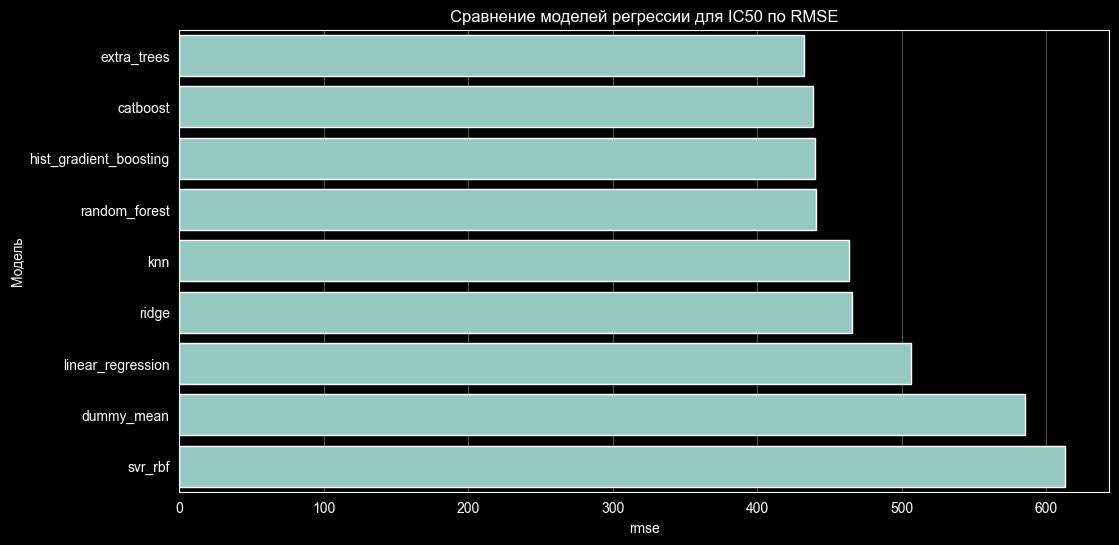

In [14]:
plot_regression_results(
    results_df=ic50_results,
    metric="rmse",
    title="Сравнение моделей регрессии для IC50 по RMSE",
)

## Модели с логарифмированием целевой переменной

In [15]:
regression_log_models = get_regression_models(use_log_target=True)

regression_log_models.keys()

dict_keys(['dummy_mean_log_target', 'linear_regression_log_target', 'ridge_log_target', 'knn_log_target', 'svr_rbf_log_target', 'random_forest_log_target', 'extra_trees_log_target', 'hist_gradient_boosting_log_target', 'catboost_log_target'])

## Запуск эксперимента с логарифмированием

In [16]:
ic50_log_results, ic50_log_fitted_models = run_regression_experiment(
    X=X,
    y=y,
    models=regression_log_models,
)

ic50_log_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape
0,catboost_log_target,290.9945,15.8631,800,201,6.4755,218.0689,447.2236,0.4004,350.1499
1,extra_trees_log_target,293.3555,18.0206,800,201,2.0428,215.4487,454.5696,0.3805,341.7562
2,hist_gradient_boosting_log_target,304.3698,16.9682,800,201,2.4950,213.5833,457.5372,0.3724,330.6374
3,random_forest_log_target,299.6235,17.4150,800,201,4.2316,221.6019,480.9150,0.3066,334.6744
4,svr_rbf_log_target,339.9072,68.9548,800,201,0.1284,225.8854,494.8329,0.2659,386.8360
5,ridge_log_target,349282461261.1344,698562229805.5881,800,201,0.0366,235.7723,505.5749,0.2337,809.1440
6,knn_log_target,306.4989,18.6894,800,201,0.0359,226.5174,523.7539,0.1776,538.7293
7,dummy_mean_log_target,374.1154,19.4625,800,201,0.0261,278.7639,627.8612,-0.1818,4593.7849
8,linear_regression_log_target,NaN,NaN,800,201,0.1613,574.9537,3407.3378,-33.8063,5144.0665


## Сохранение метрик логарифмического эксперимента

In [17]:
ic50_log_results.to_csv(
    METRICS_DIR / "regression_ic50_log_target_metrics.csv",
    index=False,
)

ic50_log_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape
0,catboost_log_target,290.9945,15.8631,800,201,6.4755,218.0689,447.2236,0.4004,350.1499
1,extra_trees_log_target,293.3555,18.0206,800,201,2.0428,215.4487,454.5696,0.3805,341.7562
2,hist_gradient_boosting_log_target,304.3698,16.9682,800,201,2.4950,213.5833,457.5372,0.3724,330.6374
3,random_forest_log_target,299.6235,17.4150,800,201,4.2316,221.6019,480.9150,0.3066,334.6744
4,svr_rbf_log_target,339.9072,68.9548,800,201,0.1284,225.8854,494.8329,0.2659,386.8360
5,ridge_log_target,349282461261.1344,698562229805.5881,800,201,0.0366,235.7723,505.5749,0.2337,809.1440
6,knn_log_target,306.4989,18.6894,800,201,0.0359,226.5174,523.7539,0.1776,538.7293
7,dummy_mean_log_target,374.1154,19.4625,800,201,0.0261,278.7639,627.8612,-0.1818,4593.7849
8,linear_regression_log_target,NaN,NaN,800,201,0.1613,574.9537,3407.3378,-33.8063,5144.0665


## График сравнения моделей с логарифмированием

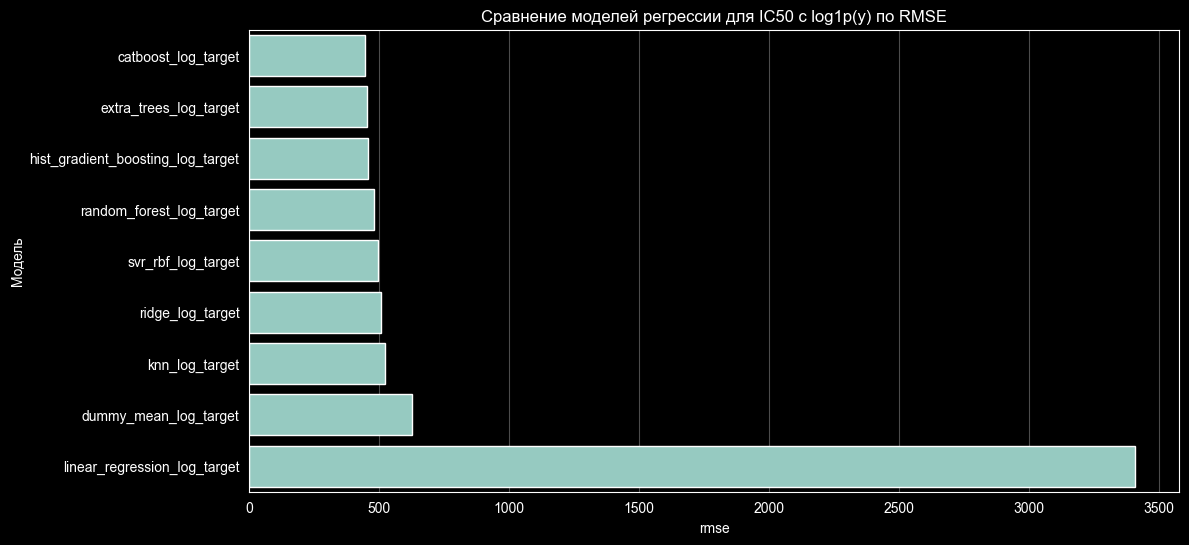

In [18]:
plot_regression_results(
    results_df=ic50_log_results,
    metric="rmse",
    title="Сравнение моделей регрессии для IC50 с log1p(y) по RMSE",
)

## Объединение результатов двух подходов

In [19]:
ic50_results_with_mode = ic50_results.copy()
ic50_results_with_mode["target_transform"] = "original"

ic50_log_results_with_mode = ic50_log_results.copy()
ic50_log_results_with_mode["target_transform"] = "log1p"

ic50_all_results = (
    pd.concat(
        [ic50_results_with_mode, ic50_log_results_with_mode],
        ignore_index=True,
    )
    .sort_values(by=["rmse", "mae"], ascending=True)
    .reset_index(drop=True)
)

ic50_all_results.to_csv(
    METRICS_DIR / "regression_ic50_all_metrics.csv",
    index=False,
)

ic50_all_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape,target_transform
0,extra_trees,286.9701,14.9218,800,201,2.2111,226.1333,432.0154,0.4405,869.1896,original
1,catboost,283.2048,18.4606,800,201,7.7179,227.0350,438.2398,0.4242,2087.9219,original
2,hist_gradient_boosting,296.5759,10.4625,800,201,2.7818,224.0760,440.0891,0.4194,1124.8280,original
3,random_forest,285.1773,16.7072,800,201,6.1834,233.9278,440.4484,0.4184,1295.5563,original
4,catboost_log_target,290.9945,15.8631,800,201,6.4755,218.0689,447.2236,0.4004,350.1499,log1p
5,extra_trees_log_target,293.3555,18.0206,800,201,2.0428,215.4487,454.5696,0.3805,341.7562,log1p
6,hist_gradient_boosting_log_target,304.3698,16.9682,800,201,2.4950,213.5833,457.5372,0.3724,330.6374,log1p
7,knn,284.4826,17.7885,800,201,0.0482,227.8030,463.4835,0.3560,1492.8749,original
8,ridge,457.8098,299.8733,800,201,0.1343,263.3173,465.4192,0.3506,4700.3805,original
9,random_forest_log_target,299.6235,17.4150,800,201,4.2316,221.6019,480.9150,0.3066,334.6744,log1p


## Выбор лучшей модели

In [20]:
best_result = ic50_all_results.iloc[0]

best_result

model               extra_trees
cv_rmse_mean           286.9701
cv_rmse_std             14.9218
train_rows                  800
test_rows                   201
fit_time_sec             2.2111
mae                    226.1333
rmse                   432.0154
r2                       0.4405
mape                   869.1896
target_transform       original
Name: 0, dtype: object

## Вывод названия лучшей модели

In [21]:
best_model_name = best_result["model"]
best_target_transform = best_result["target_transform"]

print(f"Лучшая модель: {best_model_name}")
print(f"Преобразование целевой переменной: {best_target_transform}")
print(f"RMSE: {best_result['rmse']:.4f}")
print(f"MAE: {best_result['mae']:.4f}")
print(f"R2: {best_result['r2']:.4f}")

Лучшая модель: extra_trees
Преобразование целевой переменной: original
RMSE: 432.0154
MAE: 226.1333
R2: 0.4405


## Получение лучшей обученной модели

In [22]:
if best_target_transform == "original":
    best_model = ic50_fitted_models[best_model_name]
else:
    best_model = ic50_log_fitted_models[best_model_name]

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

## Повторное train/test-разбиение для графика фактических и прогнозных значений

In [23]:
# Здесь получаем те же тестовые данные, что использовались внутри run_regression_experiment

_, X_test, _, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

y_pred = best_model.predict(X_test)

predictions_df = pd.DataFrame(
    {
        "y_true": y_test,
        "y_pred": y_pred,
    }
)

predictions_df.to_csv(
    PREDICTIONS_DIR / "regression_ic50_predictions.csv",
    index=False,
)

predictions_df.head()

,y_true,y_pred
521,1078.0625,547.6590
941,25.1994,418.4977
741,76.0706,332.5704
980,29.0001,48.2119
411,32.3445,282.7269


## График фактических и предсказанных значений

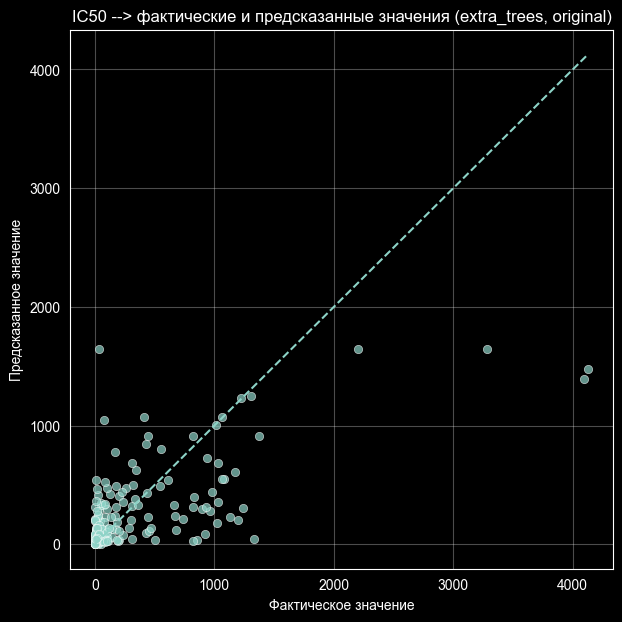

In [24]:
plot_actual_vs_predicted(
    y_true=predictions_df["y_true"],
    y_pred=predictions_df["y_pred"],
    title=f"IC50 --> фактические и предсказанные значения ({best_model_name}, {best_target_transform})",
)

## Промежуточный вывод по задаче регрессии IC50

Для прогнозирования показателя `IC50, mM` были обучены несколько моделей регрессии:
`DummyRegressor`, линейная регрессия, Ridge, KNN, SVR, Random Forest, Extra Trees,
HistGradientBoosting и CatBoost.

Эксперимент был выполнен на базовом наборе признаков, сформированном после исключения служебных столбцов
и целевых переменных `IC50, mM`, `CC50, mM` и `SI`.
На данном этапе дополнительная очистка признакового пространства
по итогам EDA еще не применялась, в данных могли оставаться константные признаки, почти константные признаки
и сильно коррелирующие между собой дескрипторы. Поэтому полученные результаты следует рассматривать как базовую
точку отсчета для дальнейшего улучшения качества моделей.

Целевая переменная `IC50, mM` имеет выраженную правостороннюю асимметрию,
большая часть наблюдений сосредоточена в области небольших значений, при этом в данных присутствуют крупные выбросы.
Максимальное значение `IC50` существенно превышает медиану, поэтому задача регрессии осложняется редкими соединениями
с очень высокими значениями целевого показателя.

Были проверены два варианта обучения:

1. обучение на исходной целевой переменной
2. обучение на логарифмированной целевой переменной `log1p(y)` с последующим обратным преобразованием предсказаний

По итогам сравнения лучшей моделью стала `ExtraTreesRegressor`, обученная на исходной целевой переменной.

Основные метрики лучшей модели:

- `RMSE`: 432.0154
- `MAE`: 226.1333
- `R2`: 0.4405

Модель заметно лучше базовой модели `DummyRegressor`, у которой `RMSE` составляет около 584.9,
а `R2` имеет отрицательное значение. Это означает, что модель действительно извлекает полезную информацию
из молекулярных дескрипторов, а не просто предсказывает среднее значение целевой переменной.

При этом качество нельзя назвать высоким, так как значение `R2 = 0.4405` показывает, что модель объясняет около 44%
вариативности целевой переменной на тестовой выборке. На графике фактических и предсказанных значений видно,
что модель лучше работает в области малых и средних значений `IC50`, но хуже восстанавливает крупные выбросы.
Для объектов с очень высоким фактическим `IC50` модель часто занижает прогноз.

Логарифмирование целевой переменной не улучшило итоговое качество по `RMSE` в исходном масштабе.
Лучшие модели с `log1p(y)` дали более низкие значения `MAPE`, однако по ключевой метрике `RMSE`
уступили модели `ExtraTreesRegressor`, обученной на исходной целевой переменной.
Поэтому для данного базового эксперимента в качестве основной модели выбран вариант без логарифмирования целевой переменной.

На следующих этапах качество модели можно попытаться улучшить за счет применения предобработки,
запланированной по итогам EDA, то есть после удаления константных и почти константных признаков, обработки сильно коррелирующих
дескрипторов, а также дополнительного подбора гиперпараметров для наиболее перспективных моделей.

## Эксперимент с предобработкой признаков

На предыдущем этапе модели обучались на базовом наборе признаков.
Базовый набор признаков был сформирован после исключения служебных столбцов и целевых переменных,
однако дополнительная очистка признакового пространства по итогам EDA еще не применялась.

Теперь применим предобработку, запланированную по результатам разведочного анализа данных:

- удалим константные признаки
- удалим почти константные признаки
- удалим сильно коррелирующие между собой признаки

Цель этого этапа -> уменьшить размерность признакового пространства,
убрать признаки без полезной вариативности и снизить дублирование информации между молекулярными дескрипторами.

In [25]:
X_preprocessed, preprocessing_report = preprocess_features(
    X,
    near_constant_threshold=0.99,
    correlation_threshold=0.9,
)

print(f"Размер X до предобработки: {X.shape}")
print(f"Размер X после предобработки: {X_preprocessed.shape}")
print(f"Удалено константных признаков: {len(preprocessing_report['constant_features'])}")
print(f"Удалено почти константных признаков: {len(preprocessing_report['near_constant_features'])}")
print(f"Удалено сильно коррелирующих признаков: {len(preprocessing_report['highly_correlated_features'])}")
print(f"Всего удалено признаков: {len(preprocessing_report['removed_features'])}")

Размер X до предобработки: (1001, 210)
Размер X после предобработки: (1001, 134)
Удалено константных признаков: 18
Удалено почти константных признаков: 15
Удалено сильно коррелирующих признаков: 43
Всего удалено признаков: 76


In [26]:
preprocessing_summary = pd.DataFrame(
    {
        "preprocessing_step": [
            "constant_features",
            "near_constant_features",
            "highly_correlated_features",
            "removed_features_total",
            "remaining_features",
        ],
        "features_count": [
            len(preprocessing_report["constant_features"]),
            len(preprocessing_report["near_constant_features"]),
            len(preprocessing_report["highly_correlated_features"]),
            len(preprocessing_report["removed_features"]),
            len(preprocessing_report["remaining_features"]),
        ],
    }
)

preprocessing_summary

,preprocessing_step,features_count
0,constant_features,18
1,near_constant_features,15
2,highly_correlated_features,43
3,removed_features_total,76
4,remaining_features,134


## Запуск эксперимента на очищенных признаках без логарифмирования целевой переменной

Сначала обучим те же модели на очищенном наборе признаков без преобразования целевой переменной.
Это позволит понять, улучшилась ли модель только за счет удаления неинформативных и избыточных признаков.

In [27]:
ic50_preprocessed_results, ic50_preprocessed_fitted_models = run_regression_experiment(
    X=X_preprocessed,
    y=y,
    models=regression_models,
)

ic50_preprocessed_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape
0,extra_trees,285.9439,14.1993,800,201,1.6809,220.4125,425.4368,0.4574,953.6947
1,catboost,284.7420,19.1160,800,201,4.6070,217.6921,427.6953,0.4516,1621.8002
2,hist_gradient_boosting,292.7190,19.2994,800,201,1.9602,227.9025,438.5216,0.4235,1453.7043
3,random_forest,282.0662,14.8323,800,201,4.1900,235.0104,439.3852,0.4212,1360.0542
4,knn,290.5143,15.9982,800,201,0.0467,229.2461,470.7392,0.3357,1508.2411
5,ridge,300.8275,22.9727,800,201,0.0297,268.9552,481.9039,0.3038,5827.3544
6,linear_regression,305.8594,20.0280,800,201,0.0455,278.4914,487.9688,0.2861,5580.6479
7,dummy_mean,341.3129,15.7786,800,201,0.0149,315.1853,584.9037,-0.0256,18642.4148
8,svr_rbf,361.0392,18.1127,800,201,0.0788,265.8810,613.5952,-0.1287,1308.5837


In [28]:
ic50_preprocessed_results.to_csv(
    METRICS_DIR / "regression_ic50_preprocessed_metrics.csv",
    index=False,
)

ic50_preprocessed_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape
0,extra_trees,285.9439,14.1993,800,201,1.6809,220.4125,425.4368,0.4574,953.6947
1,catboost,284.7420,19.1160,800,201,4.6070,217.6921,427.6953,0.4516,1621.8002
2,hist_gradient_boosting,292.7190,19.2994,800,201,1.9602,227.9025,438.5216,0.4235,1453.7043
3,random_forest,282.0662,14.8323,800,201,4.1900,235.0104,439.3852,0.4212,1360.0542
4,knn,290.5143,15.9982,800,201,0.0467,229.2461,470.7392,0.3357,1508.2411
5,ridge,300.8275,22.9727,800,201,0.0297,268.9552,481.9039,0.3038,5827.3544
6,linear_regression,305.8594,20.0280,800,201,0.0455,278.4914,487.9688,0.2861,5580.6479
7,dummy_mean,341.3129,15.7786,800,201,0.0149,315.1853,584.9037,-0.0256,18642.4148
8,svr_rbf,361.0392,18.1127,800,201,0.0788,265.8810,613.5952,-0.1287,1308.5837


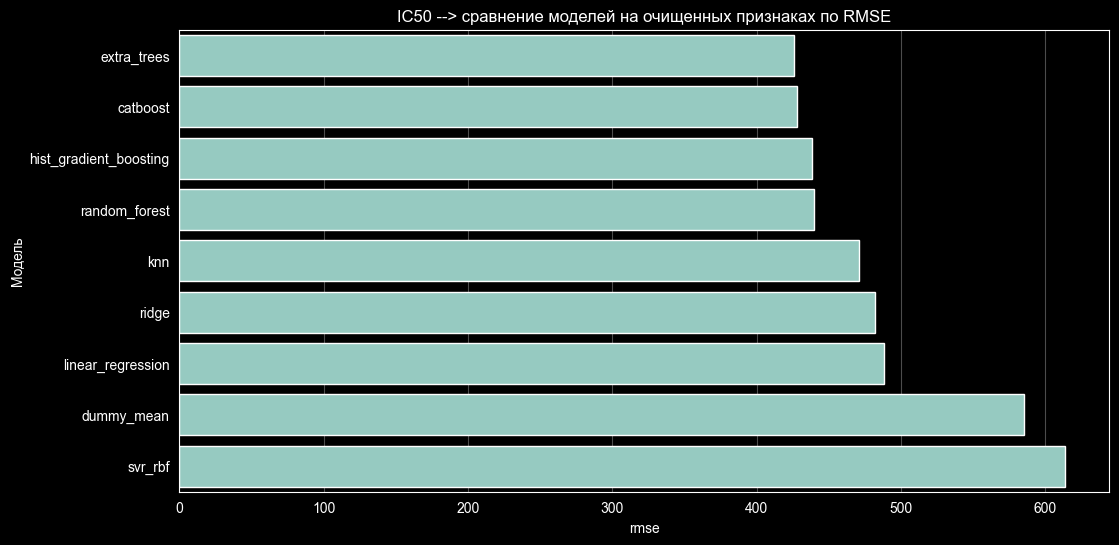

In [29]:
plot_regression_results(
    results_df=ic50_preprocessed_results,
    metric="rmse",
    title="IC50 --> сравнение моделей на очищенных признаках по RMSE",
)

## Запуск эксперимента на очищенных признаках с логарифмированием целевой переменной

Теперь проверим очищенное признаковое пространство и логарифмическое преобразование целевой переменной `log1p(y)`.
Такой подход может дать результат лучше, поскольку в ходе EDA было выявлено, что `IC50, mM` имеет правостороннюю асимметрию и выбросы.

In [30]:
regression_log_models = get_regression_models(use_log_target=True)

ic50_preprocessed_log_results, ic50_preprocessed_log_fitted_models = run_regression_experiment(
    X=X_preprocessed,
    y=y,
    models=regression_log_models,
)

ic50_preprocessed_log_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape
0,extra_trees_log_target,295.4541,15.2601,800,201,1.5235,213.9540,457.2513,0.3732,344.8782
1,hist_gradient_boosting_log_target,294.2118,15.8152,800,201,1.8981,216.0740,458.5381,0.3697,352.7344
2,catboost_log_target,291.2959,17.1632,800,201,4.3677,221.2676,468.7405,0.3413,351.8885
3,ridge_log_target,374.1292,40.1467,800,201,0.0329,237.7447,469.9224,0.3380,992.6280
4,random_forest_log_target,300.1123,16.6303,800,201,2.9946,223.3357,482.0049,0.3035,342.0041
5,svr_rbf_log_target,330.6037,51.5321,800,201,0.1097,225.2907,500.3379,0.2495,383.2127
6,knn_log_target,313.2882,16.0731,800,201,0.0342,225.0398,529.4105,0.1597,539.8323
7,linear_regression_log_target,395.8453,75.4234,800,201,0.0370,260.7883,585.3185,-0.0271,1250.1258
8,dummy_mean_log_target,374.1154,19.4625,800,201,0.0155,278.7639,627.8612,-0.1818,4593.7849


In [31]:
ic50_preprocessed_log_results.to_csv(
    METRICS_DIR / "regression_ic50_preprocessed_log_target_metrics.csv",
    index=False,
)

ic50_preprocessed_log_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape
0,extra_trees_log_target,295.4541,15.2601,800,201,1.5235,213.9540,457.2513,0.3732,344.8782
1,hist_gradient_boosting_log_target,294.2118,15.8152,800,201,1.8981,216.0740,458.5381,0.3697,352.7344
2,catboost_log_target,291.2959,17.1632,800,201,4.3677,221.2676,468.7405,0.3413,351.8885
3,ridge_log_target,374.1292,40.1467,800,201,0.0329,237.7447,469.9224,0.3380,992.6280
4,random_forest_log_target,300.1123,16.6303,800,201,2.9946,223.3357,482.0049,0.3035,342.0041
5,svr_rbf_log_target,330.6037,51.5321,800,201,0.1097,225.2907,500.3379,0.2495,383.2127
6,knn_log_target,313.2882,16.0731,800,201,0.0342,225.0398,529.4105,0.1597,539.8323
7,linear_regression_log_target,395.8453,75.4234,800,201,0.0370,260.7883,585.3185,-0.0271,1250.1258
8,dummy_mean_log_target,374.1154,19.4625,800,201,0.0155,278.7639,627.8612,-0.1818,4593.7849


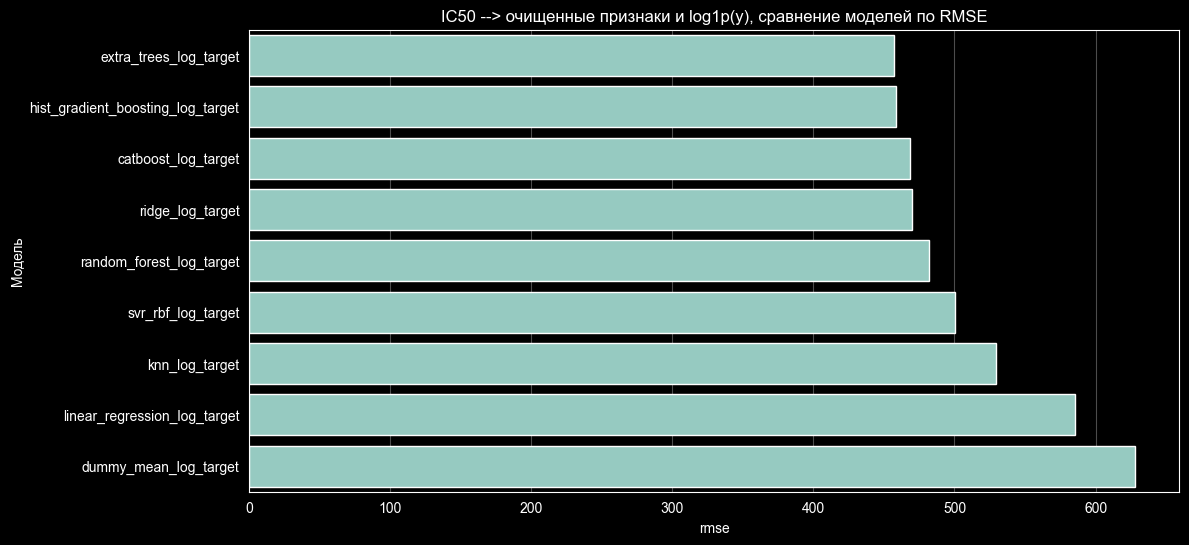

In [32]:
plot_regression_results(
    results_df=ic50_preprocessed_log_results,
    metric="rmse",
    title="IC50 --> очищенные признаки и log1p(y), сравнение моделей по RMSE",
)

## Сравнение всех вариантов эксперимента

Сравним четыре варианта построения моделей:

1. базовые признаки, исходная целевая переменная
2. базовые признаки, логарифмированная целевая переменная `log1p(y)`
3. очищенные признаки, исходная целевая переменная
4. очищенные признаки, логарифмированная целевая переменная `log1p(y)`

Это позволит оценить, повлияли ли предобработка признаков и логарифмирование целевой переменной на качество прогноза.

In [33]:
ic50_results_with_mode = ic50_results.copy()
ic50_results_with_mode["feature_set"] = "baseline_features"
ic50_results_with_mode["target_transform"] = "original"

ic50_log_results_with_mode = ic50_log_results.copy()
ic50_log_results_with_mode["feature_set"] = "baseline_features"
ic50_log_results_with_mode["target_transform"] = "log1p"

ic50_preprocessed_results_with_mode = ic50_preprocessed_results.copy()
ic50_preprocessed_results_with_mode["feature_set"] = "preprocessed_features"
ic50_preprocessed_results_with_mode["target_transform"] = "original"

ic50_preprocessed_log_results_with_mode = ic50_preprocessed_log_results.copy()
ic50_preprocessed_log_results_with_mode["feature_set"] = "preprocessed_features"
ic50_preprocessed_log_results_with_mode["target_transform"] = "log1p"

ic50_all_results = (
    pd.concat(
        [
            ic50_results_with_mode,
            ic50_log_results_with_mode,
            ic50_preprocessed_results_with_mode,
            ic50_preprocessed_log_results_with_mode,
        ],
        ignore_index=True,
    )
    .sort_values(by=["rmse", "mae"], ascending=True)
    .reset_index(drop=True)
)

ic50_all_results.to_csv(
    METRICS_DIR / "regression_ic50_all_metrics.csv",
    index=False,
)

ic50_all_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape,feature_set,target_transform
0,extra_trees,285.9439,14.1993,800,201,1.6809,220.4125,425.4368,0.4574,953.6947,preprocessed_features,original
1,catboost,284.7420,19.1160,800,201,4.6070,217.6921,427.6953,0.4516,1621.8002,preprocessed_features,original
2,extra_trees,286.9701,14.9218,800,201,2.2111,226.1333,432.0154,0.4405,869.1896,baseline_features,original
3,catboost,283.2048,18.4606,800,201,7.7179,227.0350,438.2398,0.4242,2087.9219,baseline_features,original
4,hist_gradient_boosting,292.7190,19.2994,800,201,1.9602,227.9025,438.5216,0.4235,1453.7043,preprocessed_features,original
5,random_forest,282.0662,14.8323,800,201,4.1900,235.0104,439.3852,0.4212,1360.0542,preprocessed_features,original
6,hist_gradient_boosting,296.5759,10.4625,800,201,2.7818,224.0760,440.0891,0.4194,1124.8280,baseline_features,original
7,random_forest,285.1773,16.7072,800,201,6.1834,233.9278,440.4484,0.4184,1295.5563,baseline_features,original
8,catboost_log_target,290.9945,15.8631,800,201,6.4755,218.0689,447.2236,0.4004,350.1499,baseline_features,log1p
9,extra_trees_log_target,293.3555,18.0206,800,201,2.0428,215.4487,454.5696,0.3805,341.7562,baseline_features,log1p


In [34]:
ic50_all_results[
    [
        "model",
        "feature_set",
        "target_transform",
        "cv_rmse_mean",
        "cv_rmse_std",
        "rmse",
        "mae",
        "r2",
        "mape",
        "fit_time_sec",
    ]
].head(15)

,model,feature_set,target_transform,cv_rmse_mean,cv_rmse_std,rmse,mae,r2,mape,fit_time_sec
0,extra_trees,preprocessed_features,original,285.9439,14.1993,425.4368,220.4125,0.4574,953.6947,1.6809
1,catboost,preprocessed_features,original,284.7420,19.1160,427.6953,217.6921,0.4516,1621.8002,4.6070
2,extra_trees,baseline_features,original,286.9701,14.9218,432.0154,226.1333,0.4405,869.1896,2.2111
3,catboost,baseline_features,original,283.2048,18.4606,438.2398,227.0350,0.4242,2087.9219,7.7179
4,hist_gradient_boosting,preprocessed_features,original,292.7190,19.2994,438.5216,227.9025,0.4235,1453.7043,1.9602
5,random_forest,preprocessed_features,original,282.0662,14.8323,439.3852,235.0104,0.4212,1360.0542,4.1900
6,hist_gradient_boosting,baseline_features,original,296.5759,10.4625,440.0891,224.0760,0.4194,1124.8280,2.7818
7,random_forest,baseline_features,original,285.1773,16.7072,440.4484,233.9278,0.4184,1295.5563,6.1834
8,catboost_log_target,baseline_features,log1p,290.9945,15.8631,447.2236,218.0689,0.4004,350.1499,6.4755
9,extra_trees_log_target,baseline_features,log1p,293.3555,18.0206,454.5696,215.4487,0.3805,341.7562,2.0428


## Выбор лучшей модели

Лучшей моделью считаем модель с минимальным значением `RMSE` на тестовой выборке.
Дополнительно учитываем `MAE` и `R2`, чтобы оценить устойчивость качества и способность модели объяснять вариативность целевой переменной.

In [35]:
best_result = ic50_all_results.iloc[0]

best_result

model                         extra_trees
cv_rmse_mean                     285.9439
cv_rmse_std                       14.1993
train_rows                            800
test_rows                             201
fit_time_sec                       1.6809
mae                              220.4125
rmse                             425.4368
r2                                 0.4574
mape                             953.6947
feature_set         preprocessed_features
target_transform                 original
Name: 0, dtype: object

In [36]:
best_model_name = best_result["model"]
best_feature_set = best_result["feature_set"]
best_target_transform = best_result["target_transform"]

print(f"Лучшая модель: {best_model_name}")
print(f"Набор признаков: {best_feature_set}")
print(f"Преобразование целевой переменной: {best_target_transform}")
print(f"RMSE: {best_result['rmse']:.4f}")
print(f"MAE: {best_result['mae']:.4f}")
print(f"R2: {best_result['r2']:.4f}")
print(f"MAPE: {best_result['mape']:.4f}")

Лучшая модель: extra_trees
Набор признаков: preprocessed_features
Преобразование целевой переменной: original
RMSE: 425.4368
MAE: 220.4125
R2: 0.4574
MAPE: 953.6947


In [37]:
if best_feature_set == "baseline_features" and best_target_transform == "original":
    best_model = ic50_fitted_models[best_model_name]
elif best_feature_set == "baseline_features" and best_target_transform == "log1p":
    best_model = ic50_log_fitted_models[best_model_name]
elif best_feature_set == "preprocessed_features" and best_target_transform == "original":
    best_model = ic50_preprocessed_fitted_models[best_model_name]
else:
    best_model = ic50_preprocessed_log_fitted_models[best_model_name]

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

## Анализ предсказаний лучшей модели

Построим график фактических и предсказанных значений для лучшей модели.
Если модель работает идеально, точки должны располагаться близко к диагональной линии.

In [38]:
from sklearn.model_selection import train_test_split

X_for_best_model = X if best_feature_set == "baseline_features" else X_preprocessed

_, X_test, _, y_test = train_test_split(
    X_for_best_model,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

y_pred = best_model.predict(X_test)

best_predictions = pd.DataFrame(
    {
        "y_true": y_test,
        "y_pred": y_pred,
    }
)

best_predictions.to_csv(
    PREDICTIONS_DIR / "regression_ic50_best_predictions.csv",
    index=False,
)

best_predictions.head()

,y_true,y_pred
521,1078.0625,595.1716
941,25.1994,415.3148
741,76.0706,341.4190
980,29.0001,49.9232
411,32.3445,287.8491


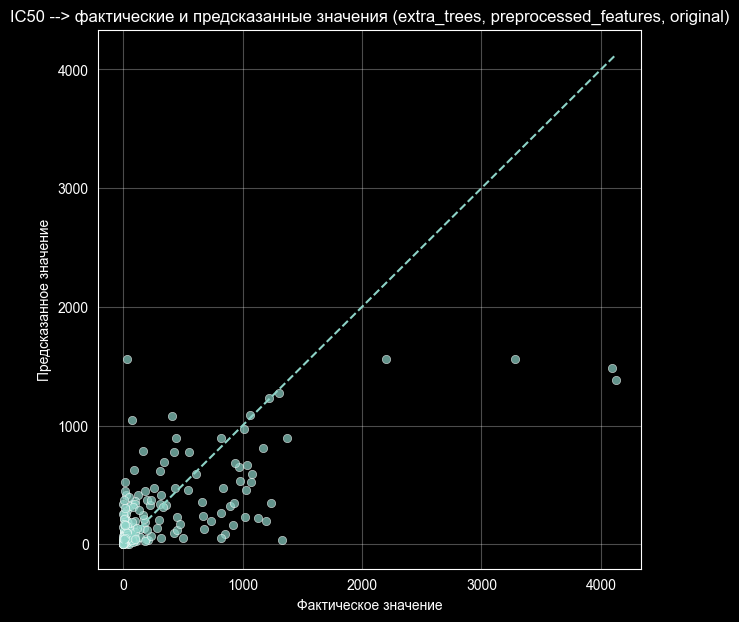

In [39]:
plot_actual_vs_predicted(
    y_true=best_predictions["y_true"],
    y_pred=best_predictions["y_pred"],
    title=(
        "IC50 --> фактические и предсказанные значения "
        f"({best_model_name}, {best_feature_set}, {best_target_transform})"
    ),
)

# Итоговый вывод по задаче регрессии IC50

На первом этапе модели были обучены на базовом наборе признаков, полученном после исключения служебных и целевых столбцов.
На втором этапе была выполнена дополнительная предобработка признакового пространства:
- удалены константные признаки
- удалены почти константные признаки
- удалены сильно коррелирующие признаки

После предобработки количество признаков сократилось с 210 до 134.
Всего было удалено 76 признаков:
- 18 константных признаков
- 15 почти константных признаков
- 43 сильно коррелирующих признака

Также были проверены два варианта работы с целевой переменной:
1. обучение на исходной целевой переменной
2. обучение на логарифмированной целевой переменной `log1p(y)` с последующим обратным преобразованием предсказаний

По итогам сравнения лучшей моделью стала `ExtraTreesRegressor`, обученная на предобработанном наборе признаков
без логарифмирования целевой переменной.

Основные метрики лучшей модели:
- `RMSE`: 425.4368
- `MAE`: 220.4125
- `R2`: 0.4574
- `MAPE`: 953.6947

По сравнению с лучшей моделью на базовых признаках качество немного улучшилось:
- `RMSE` снизился с 432.0154 до 425.4368;
- `MAE` снизился с 226.1333 до 220.4125;
- `R2` вырос с 0.4405 до 0.4574.

Это показывает, что удаление неинформативных и избыточных признаков немного повысило качество модели.
Часть удаленных признаков добавляла шум или дублировала другие дескрипторы.

Модель заметно лучше константной базовой модели `DummyRegressor`, у которой `RMSE` существенно выше,
а `R2` имеет отрицательное значение. Это означает, что модель действительно извлекает полезную информацию
из молекулярных дескрипторов, а не просто предсказывает среднее значение.

При этом качество нельзя назвать высоким: значение `R2 = 0.4574` показывает, что модель объясняет около 46%
вариативности целевой переменной на тестовой выборке. На графике фактических и предсказанных значений видно,
что модель лучше работает в области малых и средних значений `IC50`, но хуже восстанавливает крупные выбросы.
Для объектов с очень высоким фактическим `IC50` модель часто занижает прогноз.

Логарифмирование целевой переменной не улучшило итоговое качество по ключевой метрике `RMSE` в исходном масштабе.
Лучшие модели с `log1p(y)` дали более низкие значения `MAPE`, однако по `RMSE` и `R2` уступили лучшей модели,
обученной на исходной целевой переменной.

Поэтому для задачи регрессии `IC50, mM` в качестве основной модели выбран вариант:
- модель: `ExtraTreesRegressor`
- набор признаков: предобработанные признаки
- преобразование целевой переменной без логарифмирования

Итоговый выбор сделан по метрике `RMSE`, так как она сильнее штрафует крупные ошибки.
Для данной задачи это важно, поскольку в целевой переменной `IC50, mM` присутствуют большие значения и выбросы.
Дополнительно учитывалась метрика `R2`, показывающая способность модели объяснять изменчивость целевого показателя.